<a href="https://colab.research.google.com/github/stefanogiagu/corso_AML_2026/blob/main/notebooks/AML_2026_E9_UncertaintyQuantificationDNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Machine Learning for Physics 2026

## Hands-on session 9: Uncertainty Quantification on Deep Neural Networks#


**Scope:** compare different uncertainty quantification methods

**Tasks:** <p>
given a 1D dataset describing a simulation of a spread-out Bragg peak in proton therapy:

1.   train a **Bayesian-NN based on variational Inference** to solve the 1D regression task;
2.   implement a **deep ensamble method** based on a dsiscriminatve ANN, with the same archietcture as the BNN, to estimate the uncertainty and compare with the Bayesian result in terms of uncertainty bounds and computational cost;
3.   take the first ANN model trained in point 2 as a black-box, and use **conformal prediction** to assess the model uncertainty. Compare results with previous methods.

**NOTE: **no need for GPU in this exercise (model and dataset kept small)

V2.0 - 16.5.2026 <stefano.giagu@uniroma1.it>

**Dataset:** simulation of a spread-out Bragg peak in proton therapy (very small size 12 kB)

In [1]:
!wget -N http://giagu.web.cern.ch/giagu/CERN/Bragg_dataset.npz

--2026-05-18 10:22:00--  http://giagu.web.cern.ch/giagu/CERN/Bragg_dataset.npz
Resolving giagu.web.cern.ch (giagu.web.cern.ch)... 188.184.96.45, 188.184.111.229, 137.138.55.232, ...
Connecting to giagu.web.cern.ch (giagu.web.cern.ch)|188.184.96.45|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://giagu.web.cern.ch/giagu/CERN/Bragg_dataset.npz [following]
--2026-05-18 10:22:00--  https://giagu.web.cern.ch/giagu/CERN/Bragg_dataset.npz
Connecting to giagu.web.cern.ch (giagu.web.cern.ch)|188.184.96.45|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12128 (12K)
Saving to: ‘Bragg_dataset.npz’

Bragg_dataset.npz   100%[===================>]  11.84K  --.-KB/s    in 0s      

2026-05-18 10:22:01 (214 MB/s) - ‘Bragg_dataset.npz’ saved [12128/12128]



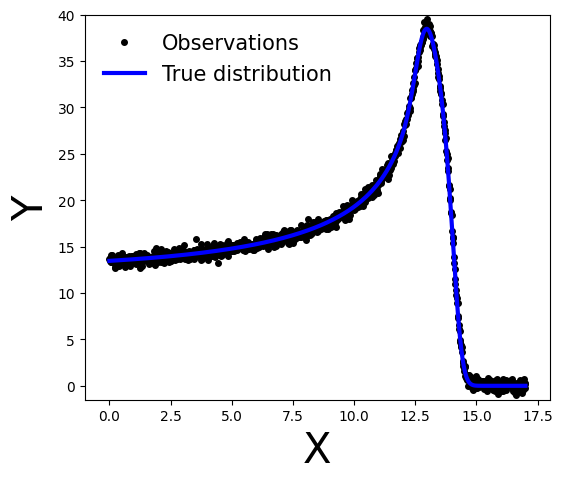

In [2]:
# Read and plot the dataset (1000 points 1D)

import numpy as np
import matplotlib.pyplot as plt

myfile = np.load('Bragg_dataset.npz')

x = np.array(myfile['X'])            #depth
y_true = np.array(myfile['Y_true'])  #deposited dose

# add noise to the data

np.random.seed(42) # random seed for reproducibility

noise_scale = 0.40
noise = noise_scale * np.random.randn(x.shape[0]) #gaussian noise

y_obs = y_true + noise               #observed data

# Set plot limits and labels
xlims = [-1.0, 18.0]
ylims = [-1.5, 40.0]

# Create function and observed data plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(x, y_obs, 'ko', markersize=4, label="Observations")
ax.plot(x, y_true, 'b-', linewidth=3, label="True distribution")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_xlabel("X", fontsize=30)
ax.set_ylabel("Y", fontsize=30)
ax.legend(loc=0, fontsize=15, frameon=False)

plt.show()

# Train a Bayesian-DNN model (a simple MLP) to predict the values of the function

**First using simple TorchBNN library**

In [3]:
#install torchbnn (https://github.com/Harry24k/bayesian-neural-network-pytorch)
!pip install torchbnn

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchbnn as bnn

In [5]:
# Bayesian DNN model: MLP with two hidden layers with hid_dim neurons and ReLU activation

# simple 200 neurons two layers dense NN with bayesian weights with nornmal priors

# just replace nn.Linear with bnn.BayesLinear (inerith from nn.Linear adding gaussian distributions for the weights + reparemetrization trick)
BDNN = nn.Sequential(
    bnn.BayesLinear(prior_mu=0, prior_sigma=0.2, in_features=1, out_features=200),   #first hidden layer
    nn.ReLU(),
    bnn.BayesLinear(prior_mu=0, prior_sigma=0.2, in_features=200, out_features=200), #second hidden layer
    nn.ReLU(),
    bnn.BayesLinear(prior_mu=0, prior_sigma=0.2, in_features=200, out_features=1),   #output layer
)

In [7]:
# loss is the sum of a recontruction loss (MSE) + kl_weight*KL divergence

mse_loss = nn.MSELoss()
kl_loss = bnn.BKLLoss() #KL divergence imlementatin in trochbnn

# weight of the KL term in the total loss
kl_weight = 1.0

# adam optimiser
optimizer = optim.Adam(BDNN.parameters(), lr=0.01)

In [8]:
# training loop

import tqdm
from tqdm.auto import trange

# Convert data to PyTorch tensors
x_train = torch.from_numpy(x.reshape(-1, 1)).float()
y_train = torch.from_numpy(y_obs).float()

progress_bar = trange(6000) #quick&dirty: batch=sample-size and no validation

for _ in progress_bar:
    pre = BDNN(x_train)
    mse = mse_loss(pre.flatten(), y_train)
    kl = kl_loss(BDNN)
    loss = mse + kl_weight*kl
    lv = loss.item()
    progress_bar.set_postfix({'loss':lv})

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print('\n Last step MSE : %2.2f, KL : %2.2f' % (mse.item(), kl.item()))

  0%|          | 0/6000 [00:00<?, ?it/s]


 Last step MSE : 3.67, KL : 0.56


In [9]:
# Now we can use the model in prediction

x_test = np.linspace(-1.,18., 4000).reshape(-1, 1)
x_test_pt = torch.tensor(x_test).float()
y_pred_list = []

for i in tqdm.tqdm(range(100)): #100 sampling for each x value
    y_pred = BDNN(x_test_pt)
    y_pred_list.append(y_pred.data.numpy())

y_preds = np.concatenate(y_pred_list, axis=1)
y_mean = np.mean(y_preds, axis=1)
y_sigma = np.std(y_preds, axis=1)

100%|██████████| 100/100 [00:01<00:00, 95.66it/s]


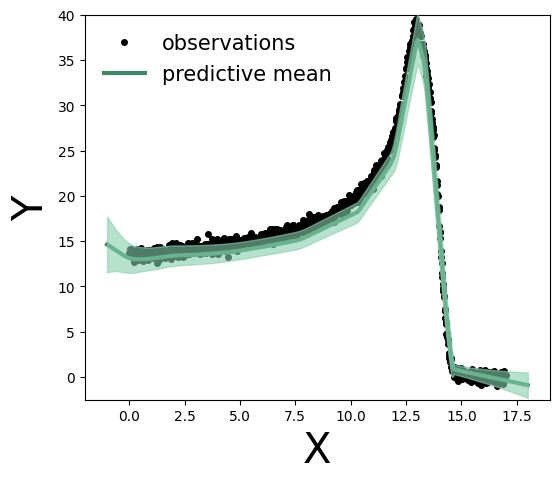

In [10]:
# plot results

fig, ax = plt.subplots(figsize=(6, 5))
xlims = [-2.0, 19.0]
ylims = [-2.5, 40.0]
plt.xlim(xlims)
plt.ylim(ylims)
plt.xlabel("X", fontsize=30)
plt.ylabel("Y", fontsize=30)

ax.plot(x, y_obs, 'ko', markersize=4, label="observations")
ax.plot(x, y_obs, 'ko', markersize=3)
ax.plot(x_test, y_mean, '-', linewidth=3, color="#408765", label="predictive mean")
ax.fill_between(x_test.ravel(), y_mean - 1.96 * y_sigma, y_mean + 1.96 * y_sigma, alpha=0.6, color='#86cfac', zorder=5) #95% bands

plt.legend(loc=0, fontsize=15, frameon=False)
plt.show()

## Bayesyan NN Using Pyro Library example

In [11]:
#install pyro library
!pip install pyro-ppl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 10.3 MB/s eta 0:00:00


A standard neural network learns fixed weights $w^*$ and $b^*$. A Bayesian neural network instead treats the weights and biases as random variables $p(w), p(b)$.

After observing data $T$, it learns a posterior distribution over weights $p(w,b|T)$. Because the exact posterior is usually impossible to compute, the code uses variational inference, where we approximate the true posterior with a simpler distribution $p(w,d|T) \approx q_\phi(w,b)$.

In this example the approximate posterior is a diagonal gaussian (so called mean-field gaussian).

In [12]:
# BNN trained with variational Inference

# see: http://pyro.ai/examples/intro_long.html#Inference-in-Pyro for details in Pyro usage

# Bayesian DNN Model: MLP with two hidden layers with hid_dim neurons and ReLU activation



import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
# note PyroModule is like a regular torch.nn.Module, but Pyro can track its probabilistic parameters (eg define parameters not as fixed tensor but as random variables sampled from a prior distribution)
import torch.nn as nn

# Definining the Bayesian-NN:MLP with two hidden layers with hid_dim neurons and ReLU activation
# gaussian priors on the weights: N(mu=0, sigma=1*I)
# prior for sigma: Uniform(0.,1.)

class SimpleBNN(PyroModule): #inherits from PyroModule
    def __init__(self, in_dim=1, out_dim=1, hid_dim=200, prior_scale=1.0): #prior_scale is The prior standard deviation for the weights and biases (=1.0 --> w_ij ~ N(0,1))
        super().__init__()

        self.activation = nn.ReLU()

        # PyroModule is a subclass of nn.torch.Module with atributes that can be modified by Pyro
        # PyroMdule[nn.Linear] create a new class that subclasses PyroModule and and torch Linear: eg a Bayesian Linear layer
        self.layer1 = PyroModule[nn.Linear](in_dim, hid_dim)  # first hidden layer [in_dim --> hid_dim]
        self.layer2 = PyroModule[nn.Linear](hid_dim, hid_dim) # second hidden layer [hid_dim --> hid_dim]
        self.layer3 = PyroModule[nn.Linear](hid_dim, out_dim) # output hidden layer [hid_dim --> out_dim]

        # Set layer parameters as random variables (this makes the layers Bayesian) by using PyroSample which allows to define a prior

        # set W_1 ~ N(0,prior_scale^2)
        self.layer1.weight = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim, in_dim]).to_event(2))
        self.layer1.bias = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim]).to_event(1))
        self.layer2.weight = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim, hid_dim]).to_event(2))
        self.layer2.bias = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim]).to_event(1))
        self.layer3.weight = PyroSample(dist.Normal(0., prior_scale).expand([out_dim, hid_dim]).to_event(2))
        self.layer3.bias = PyroSample(dist.Normal(0., prior_scale).expand([out_dim]).to_event(1))

        # NOTE: what does .expand().to_event() mean?
        # - the expand([hid_dim, in_dim]) creates a collection of Normal random variables with the desired tensor shape
        # = to_event(2) tells Pyro to treat the last two dimensions as one joint random object. e.g. instead of treating every weight as a separate sample site, Pyro treats
        #   the full weight matrix as one multivariate random variable. So for the wight matrix of dimension [200,1], .to_event(2) means the whole matrix is one event, for the bias vector .to_event(1)
        #   means the whole bias vector is one event.


    # Probabilistic model
    def forward(self, x, y=None): #y=None in inference, while is used during training (see below)

        x = x.reshape(-1, 1) #reshape input feature tensor from (batch) to (batch,1), needed by PyroModule[nn.Linear]
        x = self.activation(self.layer1(x)) #apply first layer + activation transform (note that now W_1 and b_1 are sampled random variables not fixed weights, so every time the model is evaluated, Pyro
        #                                    can sample a different neural network from the prior or posterior.
        x = self.activation(self.layer2(x)) #apply first layer + activation transform

        mu = self.layer3(x).squeeze() #apply second layer (no activation) --> (batch,1) -> (batch,)

        # observation noise: this introduce a random variable for the noise scale: sigma ~ Uniform(0,1), the model assumes the observed target values are then generated as y ~ N(mu(x), sigma^2) or more
        # precisely y = f_w(x) + epsilon with epsilon ~ Uniform(0, sigma)
        sigma = pyro.sample("sigma", dist.Uniform(0., 1.)) # Infer the response noise

        # Sampling model
        # this implements the likelihood of the data. The pyro.plate("data", x.shape[0]) tells Pyro that the observations are conditionally independent given the model parameters:
        # p(y | x,w,b,sigma) = Productory_i=1^N N(y_i | mu(x_i), sigma^2)

        with pyro.plate("data", x.shape[0]):
            obs = pyro.sample("obs", dist.Normal(mu, sigma), obs=y) #obs=y tell pyro during the training to condition the model on the obseved target y, while during prediction (y=None) to sample
            #                                                        possible observations from the predictive distribution
        return mu # the output of the model is the predictive mean

In [13]:
# train model with Variational Inference
# for more details : http://pyro.ai/examples/intro_long.html
# stochastic variational inference with the variational density q by using a normal probability density with a diagonal covariance matrix

from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal
from tqdm.auto import trange
pyro.clear_param_store() #set the initial pyro parameters store. Pyro keeps learnable variational parameters in a global parameter store. Before training, you clear it to avoid reusing
#                         parameters from previous runs (this is especially important in notebooks).

model = SimpleBNN()

# Defining the guide
# "guide" in the pyro lingo is the variational distribution. In Pyro, the model defines the generative process p(y,z), where z are latent variable as weight, biases, and sigma.
# The guide define the variational approximation q_phi(z)

# Automatically constructs a Gaussian variational posterior over all latent variables (normal q with diagonal cov. matrix)
# https://docs.pyro.ai/en/stable/infer.autoguide.html
mean_field_guide = AutoDiagonalNormal(model)# each variable is independent under q (i.e diagonal correlation matrix): q(z) = N(z| m, diag(s^2)) (called mean-field approximation).

# NOTE: the true bayesian posterior is p(W,b,sigma| x,y), very complicated and higly correlated. AutoDiagonalNormal approximate it with p(W,b,sigma) = Productory_j q(z_j) with q(z_j) = N(m_j, s_j^2)
#       This is computationally efficient, but it cannot represent posterior correlations between parameters. For example, it cannot represent that one weight increasing while another decreases gives an equally good function.

# optmizer used to update the variational parameters phi
optimizer = pyro.optim.Adam({"lr": 0.01})


# SVI is the main stochastic variational inference module than encpasule the whole machinery for doing variational inference
# user needs to provide three things: the probabilistinc model p, the guide (variational approximation) q_phi, the optimizer, and the objectibe function (ELBO)
# the ELBO loss is called Trace_ELBO()

svi = SVI(model, mean_field_guide, optimizer, loss=Trace_ELBO())
pyro.clear_param_store() #done to ensure the guide parameters are initialized fresh

# Convert data to PyTorch tensors
x_train = torch.from_numpy(x).float()
y_train = torch.from_numpy(y_obs).float()

# training
num_epochs = 30000
progress_bar = trange(num_epochs)

for epoch in progress_bar:
    loss = svi.step(x_train, y_train)
    # NOTE: each call to svi.step does one stochastic variational inference step:
    # - sample latent variables from the guide: W,b.sigma ~ q(W,b, sigma)
    # - run the model using those sampled values
    # - compute -ELBO
    # - compute gradients wrt phi and updato phi using Adam
    progress_bar.set_postfix(loss=f"{loss / x_train.shape[0]:.3f}") #loss divided for the number of training samples to display it as an approximate per-data-point loss

  0%|          | 0/30000 [00:00<?, ?it/s]

In [14]:
# reduce lr and continue training (0.01 -> 0.001) to refine the variational posterior
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model, mean_field_guide, optimizer, loss=Trace_ELBO())

num_epochs = 10000
progress_bar = trange(num_epochs)

for epoch in progress_bar:
    loss = svi.step(x_train, y_train)
    progress_bar.set_postfix(loss=f"{loss / x_train.shape[0]:.3f}")

  0%|          | 0/10000 [00:00<?, ?it/s]

In [15]:
# Now we can use the model in prediction
from pyro.infer import Predictive

# create a posterior predictive sampler: W,b, sigma ~ q_phi(W,b, sigma) and for each samples set of parameters runs the associated model
predictive = Predictive(model, guide=mean_field_guide, num_samples=500) #500 sampled neural networks from the posterior approximation

# test the model over the full function domain range
x_test = torch.linspace(-1.0, 18.0, 6000)
preds = predictive(x_test) #prdouce preds['obs'] and preds['sigma']

In [18]:
print(model(x_test).shape)
print(preds['obs'].detach().numpy().shape) # model response given a sample of the q distribution for each point in x , 500 samples

torch.Size([6000])
(500, 6000)


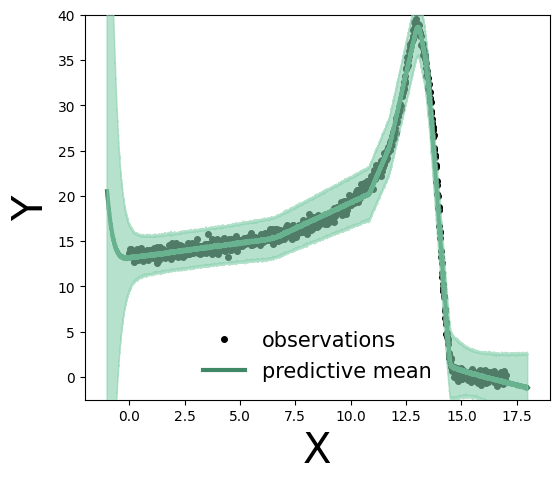

In [19]:
# Plot

y_pred = preds['obs'].T.detach().numpy().mean(axis=1) #predictions mean
y_std = preds['obs'].T.detach().numpy().std(axis=1)   #predictions std. dev.

fig, ax = plt.subplots(figsize=(6, 5))
xlims = [-2.0, 19.0]
ylims = [-2.5, 40.0]
plt.xlim(xlims)
plt.ylim(ylims)
plt.xlabel("X", fontsize=30)
plt.ylabel("Y", fontsize=30)

ax.plot(x, y_obs, 'ko', markersize=4, label="observations")
ax.plot(x, y_obs, 'ko', markersize=3)
ax.plot(x_test, y_pred, '-', linewidth=3, color="#408765", label="predictive mean")
ax.fill_between(x_test, y_pred - 1.96 * y_std, y_pred + 1.96 * y_std, alpha=0.6, color='#86cfac', zorder=5) #95% bands

plt.legend(loc=0, fontsize=15, frameon=False)
plt.show()

**NOTE: the we have trained includes two types of uncertainty:**

- uncertainy from the weights: $W,b \sim q(W,b)$, eg the epistemic uncertainty
- *intrinsic* observation noise: $\sigma \sim q(\sigma)$, eg the aleatoric uncertainty

As we have used a global $\sigma$ for the noise level, the aleatoric uncertainty does not depend on $x$ (homoscedastic).

**NOTE2:**
when we used *sigma = pyro.sample("sigma", dist.Uniform(0., 1.))* we constrained the noise to lie between 0 and 1. This may be not always appropriate (it cannot represent the noise if the actual noise scale is laregr than 1). Common alternative is to use *dist.LogNormal(0.,1.)* or *dist.HalfCauchy(1.)*, that allow positive vlues w/o an hard upper bound.


**NOTE3:**
We have used a prior_scale = 1 for layers with 200 hidden units per layer, which is a quite broad prior. Often to keep activations numerically stable is better to use smaller priors in wide layers $N(0, \text{prior_scale}^2/ n_h)$ with $n_h$ number of inputs to the layer.

# Deep Ensamble Method

Train the same MLP multiple time with different initializations of weigth matrices, use the distribution of the models' predictions for a given input $x$ to estimate mean and std. dev. prediction.

In [20]:
# The non-Bayesian equivalent of the simple BNN model used before
class SimpleNN(nn.Module):
    def __init__(self, in_dim=1, out_dim=1, hid_dim=200):
        super().__init__()

        self.activation = nn.ReLU()
        self.layer1 = nn.Linear(in_dim, hid_dim)   # Input to hidden layer
        self.layer2 = nn.Linear(hid_dim, hid_dim)  # Hidden to Hidden
        self.layer3 = nn.Linear(hid_dim, out_dim)  # Hidden to output layer

    def forward(self, x):
        x = self.activation(self.layer1(x))
        x = self.activation(self.layer2(x))
        x = self.layer3(x).squeeze()
        return x

In [21]:
# train loop function

def train_model(model, x, y):
    optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    progress_bar = trange(3000)
    for _ in progress_bar:
        optimizer.zero_grad()
        loss = criterion(y, model(x))
        progress_bar.set_postfix(loss=f'{loss:.3f}')
        loss.backward()
        optimizer.step()
    return model

In [22]:
# a single ANN result

from tqdm.auto import trange

# Convert data to PyTorch tensors
x_train = torch.from_numpy(x.reshape(-1, 1)).float()
y_train = torch.from_numpy(y_obs).float()
x_test = np.linspace(-1.,18., 4000).reshape(-1, 1)
x_test_pt = torch.tensor(x_test).float()

model2 = SimpleNN()
model2 = train_model(model2, x_train, y_train)

# test it
preds = model2(x_test_pt).clone().detach().numpy()

  0%|          | 0/3000 [00:00<?, ?it/s]

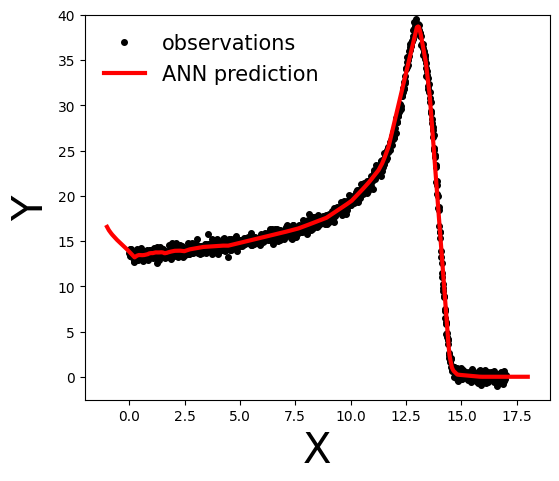

In [23]:
y_pred = preds

fig, ax = plt.subplots(figsize=(6, 5))
xlims = [-2.0, 19.0]
ylims = [-2.5, 40.0]
plt.xlim(xlims)
plt.ylim(ylims)
plt.xlabel("X", fontsize=30)
plt.ylabel("Y", fontsize=30)

ax.plot(x, y_obs, 'ko', markersize=4, label="observations")
ax.plot(x, y_obs, 'ko', markersize=3)
ax.plot(x_test, y_pred, 'r-', linewidth=3, label="ANN prediction")

plt.legend(loc=0, fontsize=15, frameon=False)
plt.show()

In [24]:
# Deep Ensamble: eg train an ensamble of SimpleNN models each one initalized with different random wights and biases

ensemble_size = 5

ensemble = [SimpleNN() for _ in range(ensemble_size)]

for model2 in ensemble:
    train_model(model2, x_train, y_train)

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

In [25]:
# calculate predictions

ens_preds = [np.array(model2(x_test_pt).clone().detach().numpy()) for model2 in ensemble]

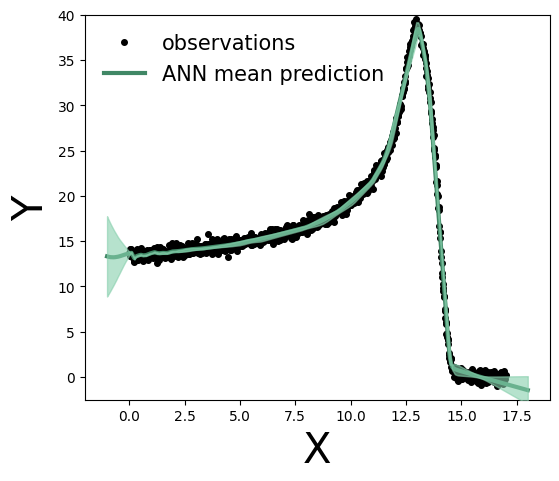

In [26]:
# plot uncertainty bands

y_pred = np.array(ens_preds)
y_mean = y_pred.mean(axis=0)
y_std = y_pred.std(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
xlims = [-2.0, 19.0]
ylims = [-2.5, 40.0]
plt.xlim(xlims)
plt.ylim(ylims)
plt.xlabel("X", fontsize=30)
plt.ylabel("Y", fontsize=30)

ax.plot(x, y_obs, 'ko', markersize=4, label="observations")
ax.plot(x, y_obs, 'ko', markersize=3)
ax.plot(x_test, y_mean, '-', linewidth=3, color="#408765", label="ANN mean prediction")
ax.fill_between(x_test.ravel(), y_mean - 1.96 * y_std, y_mean + 1.96 * y_std, alpha=0.6, color='#86cfac', zorder=5) #95% bounds

plt.legend(loc=0, fontsize=15, frameon=False)
plt.show()

# UQ using Conformal Prediction

* create a calibration dataset (statistically idependent from the training and test set)
* calculate the 95% quantiles
* plot predictions and error bars for the test set

In [27]:
# split the traing dataset in real training set (80%) and in the calibrations set (20%)

# equally spaced indexes for 20% of the x_train events
cal_idx = np.arange(len(x_train), step=1/0.2, dtype=np.int64)

# selection mask
mask = np.zeros(len(x_train), dtype=bool)
mask[cal_idx] = True

x_cali, y_cali = x_train[mask], y_train[mask]
x_train2, y_train2 = x_train[~mask], y_train[~mask]

print(x_train2.shape)
print(x_cali.shape)

torch.Size([800, 1])
torch.Size([200, 1])


In [28]:
# Train one of the previous models used in the Ensamble case

model3 = SimpleNN()
model3 = train_model(model3, x_train2, y_train2)

# test it
preds = model3(x_test_pt).clone().detach().numpy()

  0%|          | 0/3000 [00:00<?, ?it/s]

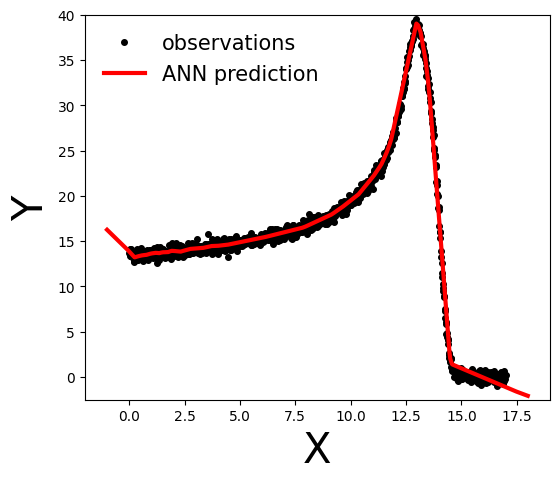

In [29]:
y_pred = preds

fig, ax = plt.subplots(figsize=(6, 5))
xlims = [-2.0, 19.0]
ylims = [-2.5, 40.0]
plt.xlim(xlims)
plt.ylim(ylims)
plt.xlabel("X", fontsize=30)
plt.ylabel("Y", fontsize=30)

ax.plot(x, y_obs, 'ko', markersize=4, label="observations")
ax.plot(x, y_obs, 'ko', markersize=3)
ax.plot(x_test, y_pred, 'r-', linewidth=3, label="ANN prediction")

plt.legend(loc=0, fontsize=15, frameon=False)
plt.show()

In [30]:
# perform the conformal prediction procedure

#1 compute calibration residuals |true - predicted| = Score
y_cali_preds = model3(x_cali).clone().detach()
resid = torch.abs(y_cali - y_cali_preds).numpy()

#2 compute (1-alpha)-quantile (alpha = 5%)of score: P(x<=q) = 1-alpha and P(x>=q) = alpha
alpha = 0.05
n = len(x_cali)
q_val = np.ceil((1 - alpha) * (n + 1)) / n
q = np.quantile(resid, q_val)

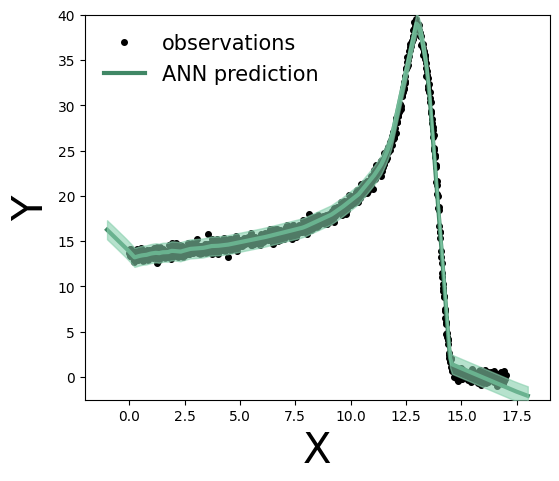

In [31]:
# plot results

y_pred = preds

fig, ax = plt.subplots(figsize=(6, 5))
xlims = [-2.0, 19.0]
ylims = [-2.5, 40.0]
plt.xlim(xlims)
plt.ylim(ylims)
plt.xlabel("X", fontsize=30)
plt.ylabel("Y", fontsize=30)

ax.plot(x, y_obs, 'ko', markersize=4, label="observations")
ax.plot(x, y_obs, 'ko', markersize=3)
ax.plot(x_test, y_pred, '-', linewidth=3, color="#408765", label="ANN prediction")
ax.fill_between(x_test.ravel(), y_pred - q, y_pred + q, alpha=0.6, color='#86cfac', zorder=5)

plt.legend(loc=0, fontsize=15, frameon=False)
plt.show()

**To do for test:**
* try to implement similar procedures for a classification task instaed of a regressione one
* try to implement a deep drop out method
* play with the pyro implementation